# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec, plot_vector, plot_vector_xy, math_bearing


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch01'

# 1 Units, Physical Quantities, and Vectors
## Problems Section 


1.61 

page 58

<img src="..//pics/Fig_P1_61.png" width=400> 

••• BIO Dislocated Shoulder. 

A patient with a dislocated shoulder
is put into a traction apparatus as shown in Fig. P1.61. The pulls $\vec{A}$ and $\vec{B}$
have equal magnitudes and must combine to produce an outward traction
force of 5.52 N on the patient’s arm. How large should these pulls be?

In [ ]:
# Given data
theta = vp.radians(32)
# A_mag = B_mag,  A_mag = (5.52/2) / cos(32)
A_mag = (5.52 / 2) / vp.cos(theta)
print(f"Magnitud of each vector: {A_mag:.2f} N")

# Check the result
A = vp.vec(A_mag * vp.cos(theta), A_mag * vp.sin(theta), 0)
B = vp.vec(A_mag * vp.cos(-theta), A_mag * vp.sin(-theta), 0)
R = A + B
R


Magnitud of each vector: 3.25 N


vector(5.52, 0, 0)

##### Ploting the Result

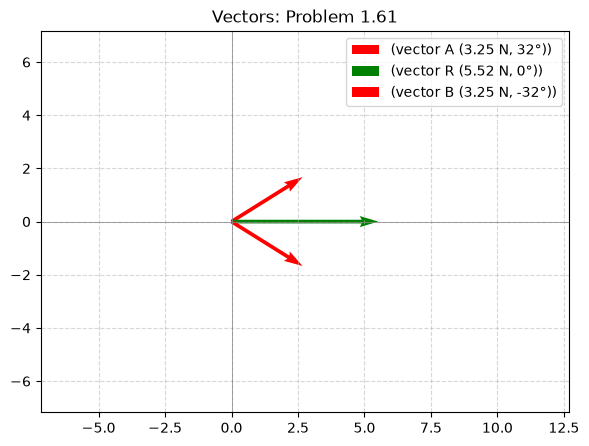

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors

vec_a = plot_vector(
    3.15,
    32,
    ax=ax,
    color="r",
    label="(vector A (3.25 N, 32°))",
)

vec_b = plot_vector_xy(
    R.x,
    R.y,
    ax=ax,
    color="g",
    label="(vector R (5.52 N, 0°))",
)

vec_r = plot_vector(
    3.15,
    -32,
    ax=ax,
    color="r",
    label="(vector B (3.25 N, -32°))",
)


plt.title("Vectors: Problem 1.61")


plt.tight_layout()
plt.show()

#### 1.62 

page 58

<img src="..//pics/Fig_P1_62.png" width=300> 


••• On a training flight in
Switzerland, a student pilot flies from
Bern to Zurich, next to Lugano, and
then to Sion (Fig. P1.62). The directions
are shown relative to north: 0°
is north, 90° is east, 180° is south, and
270° is west. Use the method of components
to find 

**(a)** the distance she has
to fly from Sion to get back to Bern,
and 

**(b)** the direction (relative to north)
she must fly to get there. Illustrate
your solutions with a vector diagram.

In [21]:
# Legs of the journey
l_1_mag = 101  # km
l_1_bearing_deg = 52
l_1_math_deg = math_bearing(l_1_bearing_deg)
l_1_angle = vp.radians(l_1_math_deg)
l_1 = vp.vec(l_1_mag * vp.cos(l_1_angle), l_1_mag * vp.sin(l_1_angle), 0)

l_2_mag = 165  # km
l_2_bearing_deg = 170
l_2_math_deg = math_bearing(l_2_bearing_deg)
l_2_angle = vp.radians(l_2_math_deg)
l_2 = vp.vec(l_2_mag * vp.cos(l_2_angle), l_2_mag * vp.sin(l_2_angle), 0)

l_3_mag = 124  # km
l_3_bearing_deg = 282
l_3_math_deg = math_bearing(l_3_bearing_deg)
l_3_angle = vp.radians(l_3_math_deg)
l_3 = vp.vec(l_3_mag * vp.cos(l_3_angle), l_3_mag * vp.sin(l_3_angle), 0)


# Displacement at leg 3
d_3 = l_1 + l_2 + l_3

l_4 = -d_3

# calculate magnitud and direction of l_4
l_4_mag = l_4.mag
l_4_angle = vp.degrees(vp.atan2(l_4.y, l_4.x)) % 360
l_4_bearing = math_bearing(l_4_angle)

print("Navigational vector (bearing)")
print(f"Vector l_4 = <{l_4_mag:.0f} km, {l_4_bearing:.1f}°>")

# Check the result
print("\nCheck the result:")
print(f"l_1 + l_2 + l_3 + l_4 = {l_1 + l_2 + l_3 + l_4}")

Navigational vector (bearing)
Vector l_4 = <76 km, 9.9°>

Check the result:
l_1 + l_2 + l_3 + l_4 = <0, 0, 0>


##### Ploting the Result

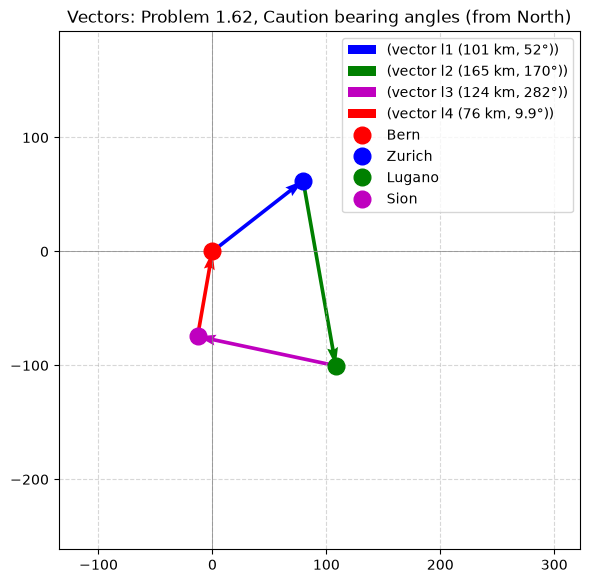

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
vec_l1 = plot_vector_xy(
    l_1.x, l_1.y, ax=ax, color="b", label="(vector l1 (101 km, 52°))"
)
vec_l2 = plot_vector_xy(
    l_2.x,
    l_2.y,
    origin=(l_1.x, l_1.y),
    ax=ax,
    color="g",
    label="(vector l2 (165 km, 170°))",
)
vec_l3 = plot_vector_xy(
    l_3.x,
    l_3.y,
    origin=((l_1 + l_2).x, (l_1 + l_2).y),
    ax=ax,
    color="m",
    label="(vector l3 (124 km, 282°))",
)
vec_l4 = plot_vector_xy(
    l_4.x,
    l_4.y,
    origin=((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y),
    ax=ax,
    color="r",
    label="(vector l4 (76 km, 9.9°))",
)


# --- Add a red asterisk at point (x=0, y=0) ---
ax.plot(0, 0, "ro", markersize=12, label="Bern")
ax.plot(l_1.x, l_1.y, "bo", markersize=12, label="Zurich")
ax.plot((l_1 + l_2).x, (l_1 + l_2).y, "go", markersize=12, label="Lugano")
ax.plot((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y, "mo", markersize=12, label="Sion")


ax.legend()
plt.title("Vectors: Problem 1.62, Caution bearing angles (from North)")


plt.tight_layout()
plt.show()